In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

/home/sahil/Desktop/LANGGRAPH/myenv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()
model = ChatOpenAI()

In [3]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    title = state['title']

    prompt = f"Create an outline for a blog post with the title: {title}"

    output = model.invoke(prompt)

    state['outline'] = output.content

    return state   

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f"Create a blog post with the title: {title} and the following outline: {outline}"

    output = model.invoke(prompt)

    state['content'] = output.content

    return state

In [6]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

#edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

#compile
workflow = graph.compile()

In [ ]:
initial_state = BlogState(title="The Benefits of AI in Healthcare")

final_state = workflow.invoke(initial_state)

In [ ]:
print(final_state['title'])
print(final_state['outline'])
print(final_state['content'])

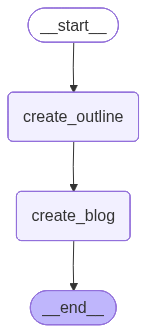

In [ ]:
workflow

In [ ]:
final_state['content']

"\n\nThe Benefits of AI in Healthcare\n\nIntroduction\n\nArtificial Intelligence (AI) has revolutionized many industries, and healthcare is no exception. AI has the potential to transform the healthcare sector by improving patient care, enhancing efficiency, reducing costs, and addressing ethical considerations. In this blog post, we will explore the various benefits of AI in healthcare and discuss the future implications of this technology.\n\nImproved Patient Care\n\nAI-driven diagnostics and treatment plans can help healthcare providers make more accurate and timely decisions, leading to better patient outcomes. Predictive analytics can also be used for early disease detection, allowing for proactive and personalized treatment strategies. By analyzing vast amounts of data, AI can enable personalized medicine tailored to individual patients' needs and preferences.\n\nEnhanced Efficiency\n\nAI can automate administrative tasks, such as scheduling appointments and processing paperwork,